# LABORATORIO 01 GRUPO 1 Regresión Lineal
Cruz Grimaldez Manuel Dominique
https://github.com/dominique01Cruz/sis420/tree/badb8b966f9026bf4cb56007377d3f1871d8df5d/Laboratorios

regresion lineal simple conexion a Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Ejercicio de programación Regresión Lineal

In [15]:
# Utilizado para manejos de directorios y rutas
import os

# Computación vectorial y científica para python
import numpy as np
import pandas as pd

# Modelos de machine learning y métricas de evaluación
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Librerías para graficación (trazado de gráficos)
import matplotlib.pyplot as pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# Llama a matplotlib a embeber gráficas dentro de los cuadernillos
%matplotlib inline

Resumen del Conjunto de Datos sobre Inundaciones Pluviales

Objetivo: El estudio buscó evaluar el riesgo de inundaciones pluviales (causadas por lluvias intensas) y desarrollar una aplicación de evaluación de susceptibilidad (SUSAP) utilizando técnicas de aprendizaje automático para mejorar la gestión de este riesgo.

Ubicación: La metrópolis de Ibadán, en el estado de Oyo, al suroeste de Nigeria. El área de estudio abarcó 5 gobiernos locales.

Metodología:

Recopilación de Datos: Se obtuvieron datos de fuentes como el USGS (Servicio Geológico de Estados Unidos) y el Copernicus Climate Data Store.

Variables: Se identificaron y utilizaron 8 "variables condicionantes" (factores de riesgo como elevación, pendiente, etc.) de un total de 53 recopiladas.

Herramientas: Se utilizó software de SIG (Sistema de Información Geográfica), específicamente ArcGIS (con su módulo de Python), para procesar y analizar los datos georreferenciados. También se interpretaron imágenes del SRTM DEM (Modelo de Elevación Digital).

Colaboración: El trabajo de campo contó con el apoyo del Proyecto de Gestión de Inundaciones Urbanas de Ibadán y Risk Management Solutions Inc.

Resultado del Dataset:

Se generó un conjunto de datos con 144,401 registros (filas).

El conjunto de datos tiene 10 columnas (que incluyen las 8 variables clave y probablemente un identificador y la clasificación de riesgo).

## 1 Regresión lineal con una variable

Para mi proyecto de regresión lineal, trabajé con un dataset de inundaciones pluviales `Pluvial_Flood_Dataset`. El objetivo era predecir un índice de susceptibilidad llamado SUSCEP. De entre todas las variables disponibles, elegí la precipitación o Rainfall como mi variable predictora porque es el factor desencadenante principal de una inundación pluvial; es la causa directa. La lógica es simple: a más lluvia, mayor es la probabilidad de que una zona se inunde. Mi modelo busca cuantificar exactamente esa relación mediante una línea recta, para poder estimar el nivel de riesgo basándonos en un dato fácil de medir como lo son los milímetros de lluvia.

In [38]:
# Para archivos Excel (.xlsx) usar pandas
data = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/preapuntes IA/Mi repositorio/Laboratorios/Lab1/Pluvial_Flood_Dataset.xlsx')

# PARA REGRESIÓN LINEAL SIMPLE:
# Seleccionar Rainfall como X y SUSCEP como y
X = data['Rainfall'].values
y = data['SUSCEP'].values

m = y.size  # m = número de ejemplos de entrenamiento

print("Primeros 5 ejemplos del dataset:")
for i in range(5):
    print(f"x = {X[i]:.2f}, y = {y[i]}")

print(f"\nNúmero de ejemplos de entrenamiento: {m}")

Primeros 5 ejemplos del dataset:
x = 101.52, y = Very_High
x = 80.41, y = Very_High
x = 78.99, y = Very_High
x = 81.95, y = Very_High
x = 85.87, y = Very_High

Número de ejemplos de entrenamiento: 144401


In [39]:
print(data)

               X         Y      Slope    Curvature       Aspect       TWI  \
0       3.909444  7.443056  46.686142 -3.888000e+09   45.000000 -3.250368   
1       3.908611  7.442778  52.151768  1.296000e+09   60.945396 -4.313832   
2       3.908889  7.442778  66.484085  0.000000e+00   67.619865 -8.327622   
3       3.909167  7.442778  58.007183 -2.592000e+09   38.659809 -4.707937   
4       3.909444  7.442778  60.503792 -1.296000e+09  351.869904 -5.985817   
...          ...       ...        ...           ...         ...       ...   
144396  3.864167  7.311667  70.837776  1.296000e+09  272.489563 -8.552538   
144397  3.864444  7.311667  72.578880  1.296000e+09  295.559967 -9.347733   
144398  3.864722  7.311667  70.667946  6.480000e+09  322.125031 -9.236161   
144399  3.859722  7.311389  61.980232  1.296000e+09  183.814072 -8.819514   
144400  3.860000  7.311389  68.768135  5.184000e+09  150.945389 -9.134113   

           FA  Drainage    Rainfall     SUSCEP  
0       147.0  228.8528  1

Convertir Texto a Números

In [40]:
# Mapear las categorías de texto a valores numéricos
suscep_mapping = {
    'No_Flood': 1,
    'Low': 2,
    'Moderate': 3,
    'High': 4,
    'Very_High': 5
}

# Aplicar el mapeo a la variable y
y_numeric = np.array([suscep_mapping[valor] for valor in y])

# Verificar la conversión
print("\nDespués de la conversión a numérico:")
print("Primeros 5 ejemplos (Rainfall, SUSCEP_numeric):")
for i in range(5):
    print(f"x = {X[i]:.2f}, y = {y_numeric[i]}")

print(f"\nValores únicos en y_numeric: {np.unique(y_numeric)}")


Después de la conversión a numérico:
Primeros 5 ejemplos (Rainfall, SUSCEP_numeric):
x = 101.52, y = 5
x = 80.41, y = 5
x = 78.99, y = 5
x = 81.95, y = 5
x = 85.87, y = 5

Valores únicos en y_numeric: [1 2 3 4 5]


In [41]:
print(X)

[101.51561644  80.40986301  78.98684932 ...  62.88684932  66.04493151
 101.51561644]


In [42]:
print(y_numeric)

[5 5 5 ... 2 2 2]


In [43]:
print(X.size)

144401


### 1.1 Trazar los datos

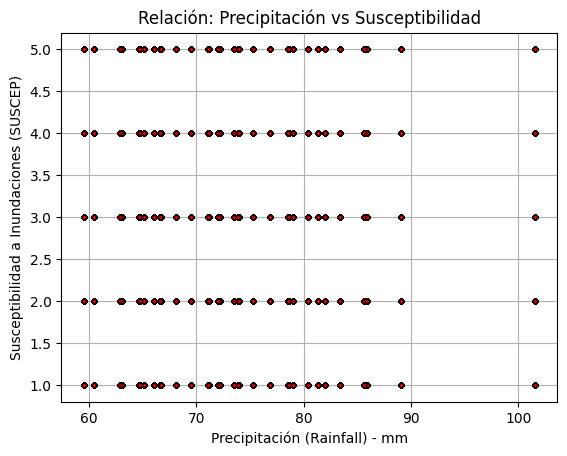

In [44]:
# 3. Graficar (USANDO y_numeric)
def plotData(x, y):
    fig = pyplot.figure()
    pyplot.plot(x, y, 'ro', ms=3, mec='k', alpha=0.6)
    pyplot.ylabel('Susceptibilidad a Inundaciones (SUSCEP)')
    pyplot.xlabel('Precipitación (Rainfall) - mm')
    pyplot.title('Relación: Precipitación vs Susceptibilidad')
    pyplot.grid(True)

plotData(X, y_numeric)  # usando valores numéricos


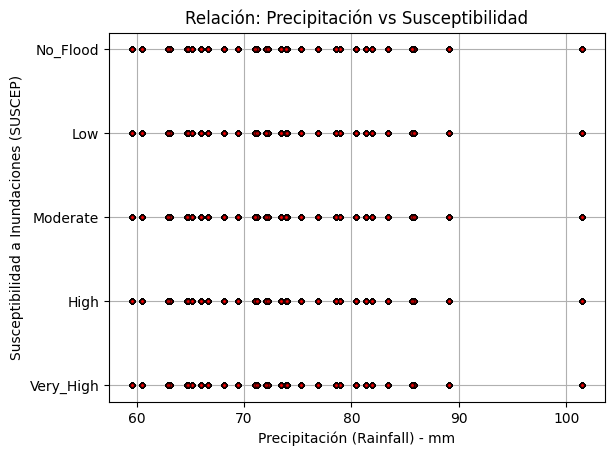

In [23]:
plotData(X, y)

In [24]:
# ?pyplot.plot

# <a id="section2"></a>
### 1.2 Descenso por el gradiente

#### 1.2.1 Ecuaciones de actualización

El objetivo de la regresion lineal es minimizar la funcion de costo

$$ J(\theta) = \frac{1}{2m} \sum_{i=1}^m \left( h_{\theta}(x^{(i)}) - y^{(i)}\right)^2$$

donde la hipotesis $h_\theta(x)$ esta dada por el modelo lineal
$$ h_\theta(x) = \theta^Tx = \theta_0 + \theta_1 x_1$$

Los parametros del modelo son los valores $\theta_j$. Estos son los valores que se ajustaran al costo minimo $J(\theta)$. Un camino para lograr esto es usar el algoritmo por lotes del descenso por el gradiente. En el descenso por el gradiente por lotes, cada iteracion ejecuta una actualizacion
$$ \theta_j = \theta_j - \alpha \frac{1}{m} \sum_{i=1}^m \left( h_\theta(x^{(i)}) - y^{(i)}\right)x_j^{(i)} \qquad \text{actualizacion simultanea } \theta_j \text{ for all } j$$

Con cada paso del descenso por el gradiente, los parametros $\theta_j$ son mas cercanos a los valores optimos que permitiran lograr el costo mas bajo J($\theta$).

#### 1.2.2 Implementación

In [45]:
# Agrega una columna de unos a X. La funcion stack de numpy une matrices a lo largo de un eje dado.
# El primer eje (eje = 0) se refiere a filas (ejemplos de entrenamiento)
# y el segundo eje (eje = 1) se refiere a columnas (características).

X = np.stack([np.ones(m), X], axis=1)

In [46]:
print(X)

[[  1.         101.51561644]
 [  1.          80.40986301]
 [  1.          78.98684932]
 ...
 [  1.          62.88684932]
 [  1.          66.04493151]
 [  1.         101.51561644]]


<a id="section2"></a>
#### 1.2.3 Cálculo del costo $J(\theta)$

In [47]:
def calcularCosto(X, y, theta):
    # inicializa algunos valores importantes
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    # h = np.dot(X, theta)
    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

Ejemplo de funcionamiento de la funcion computeCoste con dos valores diferentes de $\theta$.

In [48]:
# usar y_numeric en lugar de y
J = calcularCosto(X, y_numeric, theta=np.array([0.0, 0.0]))
print('Con theta = [0, 0] \nCosto calculado = %.2f' % J)

# pruebas adicionales de la función de costes
J = calcularCosto(X, y_numeric, theta=np.array([0.5, 0.5]))
print('Con theta = [0.5, 0.5]\nCosto calculado = %.2f' % J)

J = calcularCosto(X, y_numeric, theta=np.array([0.6, 0.6]))
print('Con theta = [0.6, 0.6]\nCosto calculado = %.2f' % J)

J = calcularCosto(X, y_numeric, theta=np.array([0.7, 0.7]))
print('Con theta = [0.7, 0.7]\nCosto calculado = %.2f' % J)

J = calcularCosto(X, y_numeric, theta=np.array([0.8, 0.8]))
print('Con theta = [0.8, 0.8]\nCosto calculado = %.2f' % J)

J = calcularCosto(X, y_numeric, theta=np.array([0.75, 0.75]))
print('Con theta = [0.75, 0.75]\nCosto calculado = %.2f' % J)

Con theta = [0, 0] 
Costo calculado = 5.63
Con theta = [0.5, 0.5]
Costo calculado = 615.36
Con theta = [0.6, 0.6]
Costo calculado = 911.99
Con theta = [0.7, 0.7]
Costo calculado = 1266.85
Con theta = [0.8, 0.8]
Costo calculado = 1679.93
Con theta = [0.75, 0.75]
Costo calculado = 1466.11


<a id="section3"></a>
#### 1.2.4 Descenso por el gradiente

El costo $J(\theta)$ esta parametrizado por el vector $\theta$, no $X$ y $y$. Donde hay que minimizar el valor de $J(\theta)$ cambiando los valores del vector $\theta$. Una buena manera de verificar si el descenso por el gradiente esta trabajando correctamente es ver los valores de $J(\theta)$ y verificar si estos decresen en cada paso.

<div class="alert alert-box alert-warning">
**Vectores y matrices en `numpy`** - Importantes notas para implementación
Un vector en `numpy` es un array de una diemension, por ejemplo `np.array([1, 2, 3])` es un vector. Una matriz en `numpy` is un arreglo de dos dimensiones, por ejemplo  `np.array([[1, 2, 3], [4, 5, 6]])`. Sin embargo, lo siguiente todavía se considera una matriz `np.array ([[1, 2, 3]])` ya que tiene dos dimensiones, incluso si tiene una forma de 1x3 (que parece un vector).

In [51]:
def gradientDescent(X, y, theta, alpha, num_iters):
    # Inicializa algunos valores importantes
    m = y.shape[0]  # numero de ejemplos de entrenamiento

    # hace una copia de theta, para evitar cambiar la matriz original,
    # ya que las matrices numpy se pasan por referencia a las funciones
    theta = theta.copy()

    J_history = [] # Lista que se utiliza para almacenar el costo en cada iteración

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        # save the cost J in every iteration
        J_history.append(calcularCosto(X, y, theta))

    return theta, J_history

Se inicializan los parametros $\theta$ con 0 y la taza de aprendizaje $\alpha$ con 0.01.

In [54]:
# inicializa los parametros de ajuste
theta = np.zeros(2)

# configuraciones para el descenso por el gradiente (VALORES MÁS CONSERVADORES)
iterations = 1000
alpha = 0.0001

theta, J_history = gradientDescent(X, y_numeric, theta, alpha, iterations)
print('Theta encontrada por descenso gradiente: {:.6f}, {:.6f}'.format(*theta))
print('Ecuación: SUSCEP = {:.6f} + {:.6f}*Rainfall'.format(theta[0], theta[1]))
print('Costo final J(θ): {:.6f}'.format(J_history[-1]))

Theta encontrada por descenso gradiente: 0.004881, 0.041030
Ecuación: SUSCEP = 0.004881 + 0.041030*Rainfall
Costo final J(θ): 0.839854


Se utilizan los parametros finales para grafical la linea.

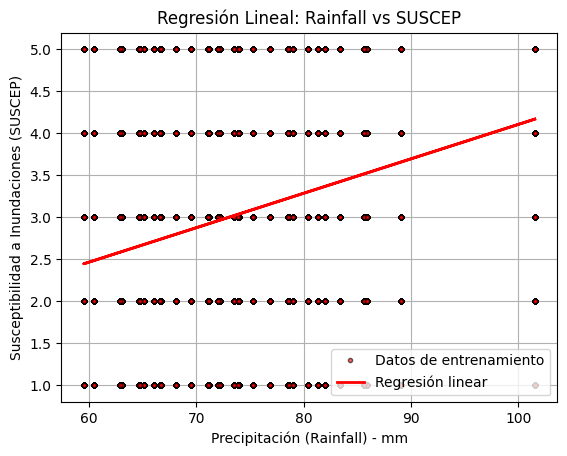

In [55]:
# grafica la linea de ajuste
plotData(X[:, 1], y_numeric)  # Usar y_numeric en lugar de y
pyplot.plot(X[:, 1], np.dot(X, theta), '-', color='red', linewidth=2)
pyplot.ylabel('Susceptibilidad a Inundaciones (SUSCEP)')
pyplot.xlabel('Precipitación (Rainfall) - mm')
pyplot.title('Regresión Lineal: Rainfall vs SUSCEP')
pyplot.legend(['Datos de entrenamiento', 'Regresión linear'])
pyplot.grid(True)
pyplot.show()

Los valores finales de $\theta$ se utilizaran para realizar predicciones.

In [56]:
# Predecir valores de susceptibilidad para diferentes niveles de lluvia
predict1 = np.dot([1, 100], theta)  # [bias term, rainfall value]
print('Para una precipitación = 100 mm, se predice una susceptibilidad de {:.2f}'.format(predict1))

predict2 = np.dot([1, 200], theta)
print('Para una precipitación = 200 mm, se predice una susceptibilidad de {:.2f}'.format(predict2))

# Si quieres más predicciones
print('\nMás predicciones:')
for rainfall in [50, 150, 250]:
    prediccion = np.dot([1, rainfall], theta)
    print(f'Para Rainfall = {rainfall} mm, SUSCEP predicho = {prediccion:.2f}')

Para una precipitación = 100 mm, se predice una susceptibilidad de 4.11
Para una precipitación = 200 mm, se predice una susceptibilidad de 8.21

Más predicciones:
Para Rainfall = 50 mm, SUSCEP predicho = 2.06
Para Rainfall = 150 mm, SUSCEP predicho = 6.16
Para Rainfall = 250 mm, SUSCEP predicho = 10.26


### 1.4 Visualizar $J(\theta)$

Para comprender mejor la función de costo $J(\theta)$, se graficará la funcion de costo en 2 dimenciones con los valores de $\theta_0$ y $\theta_1$.

El proposito de graficar el costo para observar como $J(\theta)$ varia con cambios en $\theta_0$ y $\theta_1$. La función de costo  $J(\theta)$ tiene forma de una cuenca con un minimo global. (Esto es mas facil observar en los contornos de una superficie 3D). El minimo es el punto optimo para $\theta_0$ y $\theta_1$, en cada paso del descenso por el gradiente se mueve mas cerca a este punto.

Visualización de la función de costo J(θ)


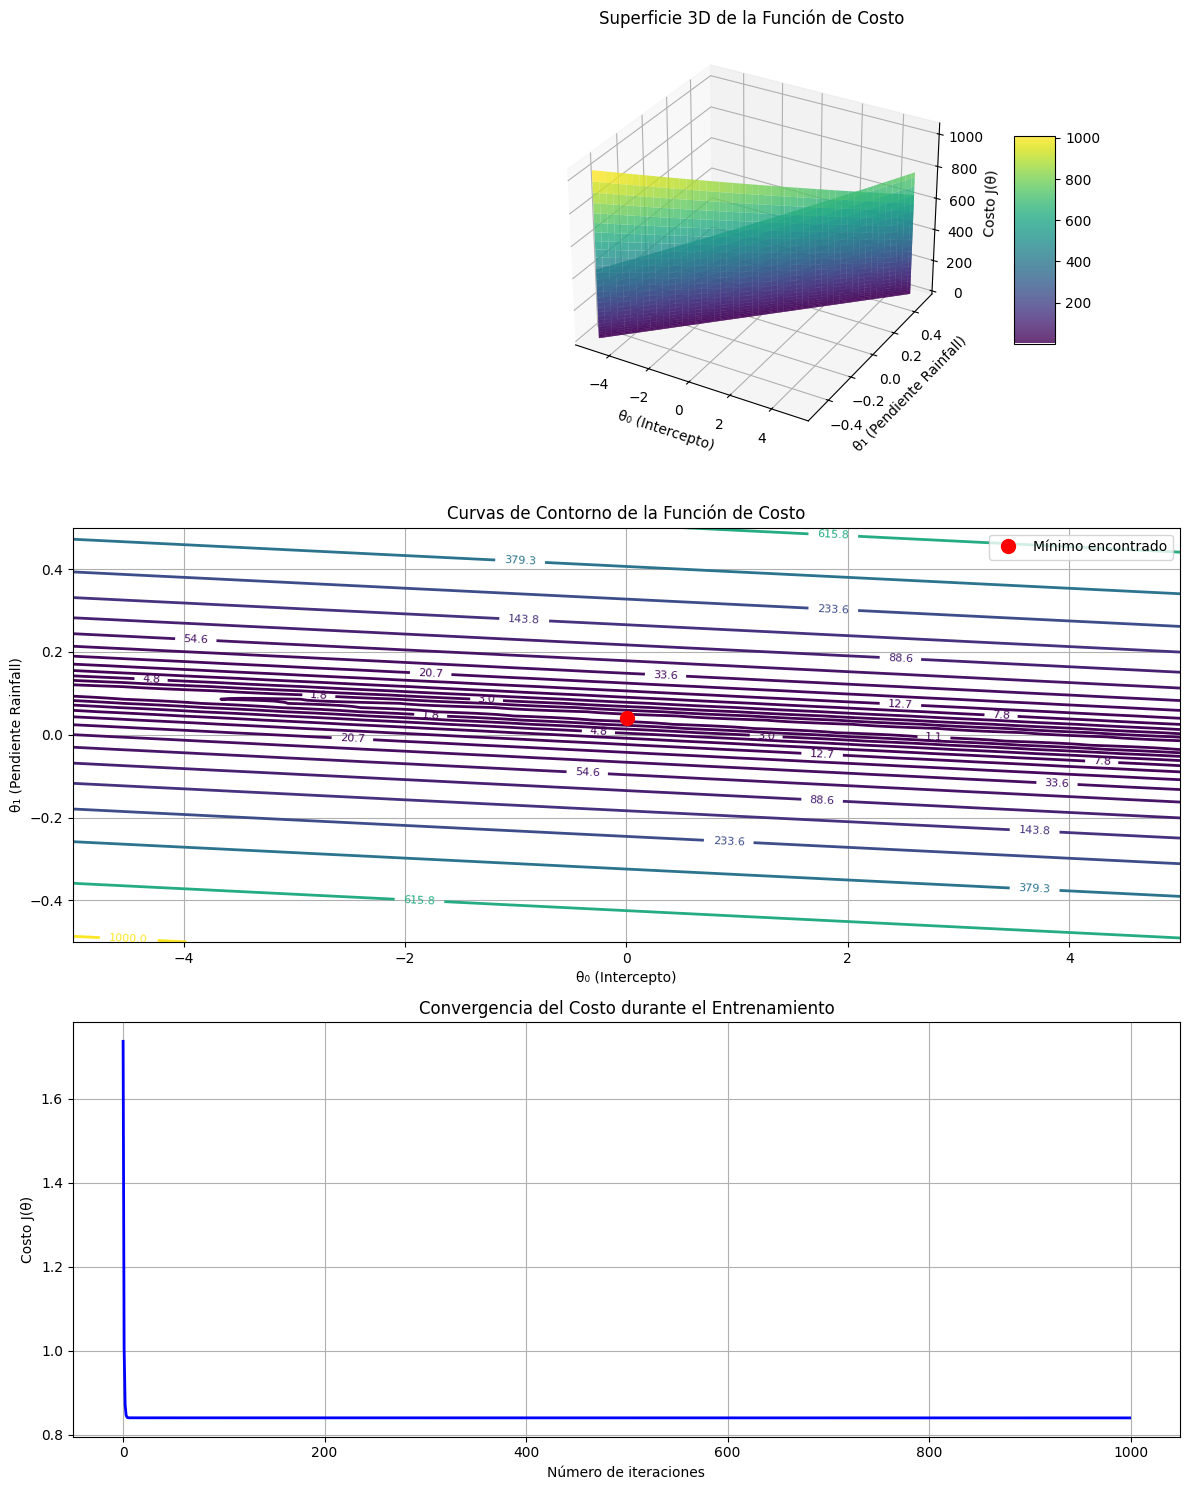

In [57]:
# 1.4 Visualizar J(θ) para el dataset de inundaciones
print("Visualización de la función de costo J(θ)")
print("=" * 50)

# cuadrícula sobre la que se calcula J (AJUSTAR RANGOS para tu dataset)
theta0_vals = np.linspace(-5, 5, 100)      # Rango ajustado para θ₀
theta1_vals = np.linspace(-0.5, 0.5, 100)  # Rango ajustado para θ₁ (más pequeño)

# inicializa J_vals con una matriz de 0's
J_vals = np.zeros((theta0_vals.shape[0], theta1_vals.shape[0]))

# Completar J_vals (USANDO y_numeric)
for i, theta0 in enumerate(theta0_vals):
    for j, theta1 in enumerate(theta1_vals):
        J_vals[i, j] = calcularCosto(X, y_numeric, [theta0, theta1])  # ¡y_numeric!

# Debido a la forma en que funcionan las cuadrículas en el comando surf,
# se necesita transponer J_vals antes de llamar a surf, o de lo contrario los ejes se invertirán
J_vals = J_vals.T

# graficar la superficie 3D
fig = pyplot.figure(figsize=(12, 15))
ax = fig.add_subplot(311, projection='3d')
surf = ax.plot_surface(theta0_vals, theta1_vals, J_vals, cmap='viridis', alpha=0.8)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
ax.set_xlabel('θ₀ (Intercepto)')
ax.set_ylabel('θ₁ (Pendiente Rainfall)')
ax.set_zlabel('Costo J(θ)')
ax.set_title('Superficie 3D de la Función de Costo')

# graficar contornos 2D
ax = pyplot.subplot(312)
contour = pyplot.contour(theta0_vals, theta1_vals, J_vals,
                        levels=np.logspace(-1, 3, 20),  # Niveles ajustados
                        cmap='viridis', linewidths=2)
pyplot.clabel(contour, inline=1, fontsize=8)
pyplot.xlabel('θ₀ (Intercepto)')
pyplot.ylabel('θ₁ (Pendiente Rainfall)')

# Marcar el mínimo encontrado (si theta es válido)
if not np.isnan(theta).any():
    pyplot.plot(theta[0], theta[1], 'ro', ms=10, lw=2, label='Mínimo encontrado')

pyplot.title('Curvas de Contorno de la Función de Costo')
pyplot.legend()
pyplot.grid(True)

# Grafica la convergencia del costo durante el entrenamiento
ax = pyplot.subplot(313)
pyplot.plot(np.arange(len(J_history)), J_history, 'b-', lw=2)
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J(θ)')
pyplot.title('Convergencia del Costo durante el Entrenamiento')
pyplot.grid(True)

pyplot.tight_layout()
pyplot.show()